# Régression Logistique
Analyse colinéarité → drop → entraînement → évaluation

In [25]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss,
    classification_report, precision_recall_curve,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler

ROOT = Path("../..").resolve()

with open(ROOT / "config.yaml") as f:
    CONFIG = yaml.safe_load(f)

def cfg_get(cfg, key, default):
    node = cfg
    for part in key.split("."):
        if not isinstance(node, dict) or part not in node:
            return default
        node = node[part]
    return node

def cfg_path(cfg, key, default):
    val = cfg_get(cfg, key, default)
    p = Path(val)
    return p if p.is_absolute() else ROOT / p

TARGET_COL   = cfg_get(CONFIG, "common.target_col", "outcome")
RANDOM_STATE = cfg_get(CONFIG, "common.random_state", 2)

RUN_TEST              = cfg_get(CONFIG, "model_logreg.run_test", False)
FEATURES_TO_DROP      = cfg_get(CONFIG, "model.features_to_drop", ["Order"])
critical_cols         = cfg_get(CONFIG, "model_logreg.critical_cols",
                                ["age", "clinical_stage", "pirads", "prostate_volume", "psa_density"])
critical_nan_pct      = cfg_get(CONFIG, "model_logreg.critical_nan_threshold_pct", 5.0)
imputation_strategy   = cfg_get(CONFIG, "model_logreg.imputation_strategy", "median")
C                     = cfg_get(CONFIG, "model_logreg.C", 1.0)
PENALTY               = cfg_get(CONFIG, "model_logreg.penalty", "l2")
MAX_ITER              = cfg_get(CONFIG, "model_logreg.max_iter", 1000)
common_threshold      = cfg_get(CONFIG, "model_logreg.common_threshold", 0.5)
TUNE_C                = cfg_get(CONFIG, "model_logreg.tune_C", False)
C_GRID                = cfg_get(CONFIG, "model_logreg.C_grid", [0.001, 0.01, 0.1, 1.0, 10.0, 100.0])
N_FOLDS               = cfg_get(CONFIG, "model_logreg.n_folds", 5)
APPLY_POWER_TRANSFORM = cfg_get(CONFIG, "model_logreg.apply_power_transform", False)
CONTINUOUS_COLS       = cfg_get(CONFIG, "model_logreg.continuous_cols",
                                ["age", "prostate_volume", "psa_density", "pirads", "nb_susp_lesions"])

DATA_TRAIN = cfg_path(CONFIG, "paths.train", "data/train_df.csv")
DATA_TEST  = cfg_path(CONFIG, "paths.test",  "data/test_df.csv")

df_train = pd.read_csv(DATA_TRAIN, sep=";")
df_train["age"]         = pd.to_numeric(df_train["age"],         errors="coerce")
df_train["psa_density"] = pd.to_numeric(df_train["psa_density"], errors="coerce")

existing_to_drop = [f for f in FEATURES_TO_DROP if f in df_train.columns]
df_train = df_train.drop(columns=existing_to_drop)

print(f"Train : {df_train.shape[0]} patients, {df_train.shape[1]-1} features")
print(f"Dropped (config) : {existing_to_drop}")
print(f"RUN_TEST : {RUN_TEST}")

Train : 3879 patients, 14 features
Dropped (config) : ['Order', 'contralateral_suspicious', 'contralateral_pirads', 'contralateral_diameter', 'family_history', 'diameter', 'psa', 'ant']
RUN_TEST : True


## 1. NaN summary

In [26]:
feature_cols = [c for c in df_train.columns if c != TARGET_COL]
nan_pct = (df_train[feature_cols].isna().sum() / len(df_train) * 100).sort_values(ascending=False)
nan_pct = nan_pct[nan_pct > 0]
print(f"NaN % par feature (train, n={len(df_train)}) :")
print(nan_pct.round(1).to_string())

NaN % par feature (train, n=3879) :
psa_density             3.7
prostate_volume         3.4
nb_susp_lesions         2.3
pirads                  1.9
prev_neg_trus_biopsy    0.3
age                     0.0


## 2. Matrice de colinéarité (Pearson)

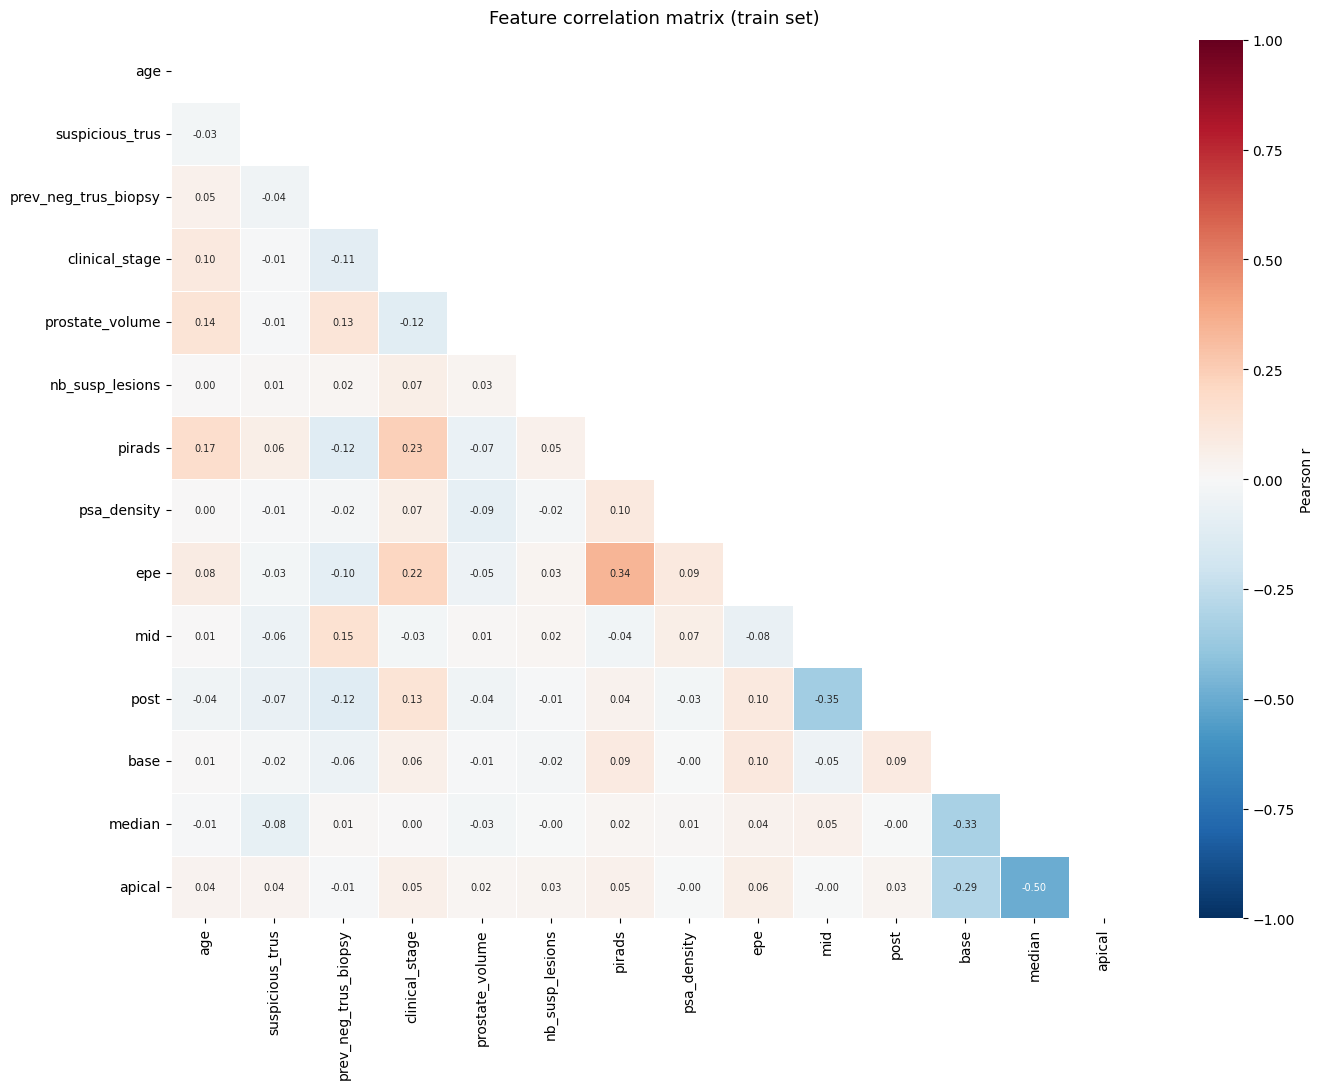

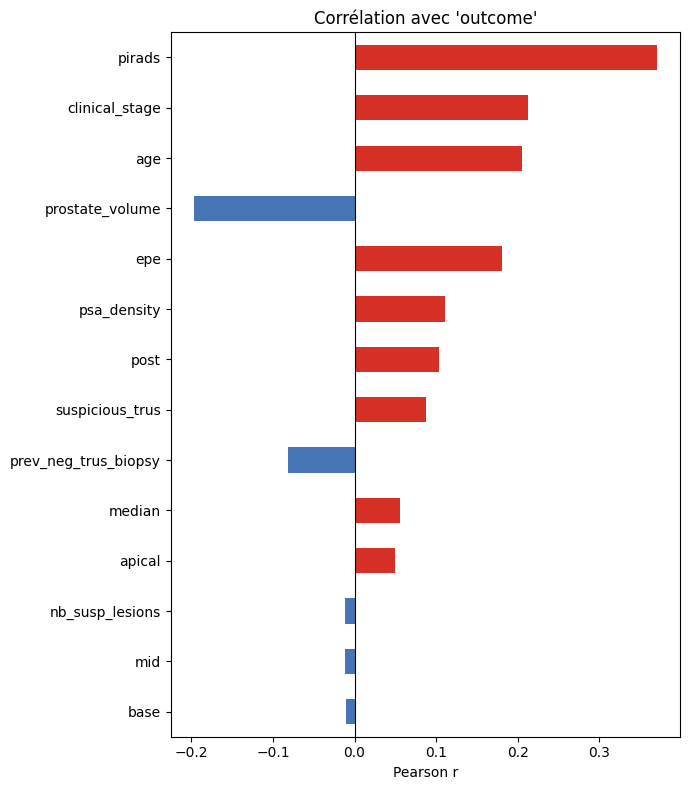

Paires |r| > 0.5 :
  Aucune.


In [27]:
num_cols = df_train[feature_cols].select_dtypes(include="number").columns.tolist()
corr = df_train[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={"size": 7},
    cbar_kws={"label": "Pearson r"}
)
ax.set_title("Feature correlation matrix (train set)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Corrélation avec l'outcome
corr_outcome = (
    df_train[num_cols + [TARGET_COL]]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=True)
)
fig, ax = plt.subplots(figsize=(7, 8))
colors = ["#d73027" if v > 0 else "#4575b4" for v in corr_outcome]
corr_outcome.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r")
ax.set_title(f"Corrélation avec '{TARGET_COL}'", fontsize=12)
plt.tight_layout()
plt.show()

# Paires fortement corrélées
threshold = 0.5
print(f"Paires |r| > {threshold} :")
found = False
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > threshold:
            a, b = corr.columns[i], corr.columns[j]
            print(f"  {a:35s} <-> {b:35s}  r = {r:+.3f}")
            found = True
if not found:
    print("  Aucune.")

## 3. Drop supplémentaire (optionnel)
Ajouter ici les features à exclure après analyse de la matrice.

In [ ]:
EXTRA_FEATURES_TO_DROP = [
    # none atm
]

extra_existing = [f for f in EXTRA_FEATURES_TO_DROP if f in df_train.columns]
extra_missing  = [f for f in EXTRA_FEATURES_TO_DROP if f not in df_train.columns]

if extra_existing:
    df_train = df_train.drop(columns=extra_existing)
    print(f"Dropped (extra) : {extra_existing}")
else:
    print("Aucun drop supplémentaire.")
if extra_missing:
    print(f"⚠ Introuvables : {extra_missing}")

print(f"Features restantes : {df_train.shape[1]-1}")

Aucun drop supplémentaire.
Features restantes : 14


## 4. Entraînement — Régression Logistique

In [ ]:
X = df_train.drop(columns=[TARGET_COL])
y = df_train[TARGET_COL]

# Drop lignes avec NaN dans les colonnes critiques si taux > seuil
critical_present  = [c for c in critical_cols if c in X.columns]
critical_nan      = (X[critical_present].isna().sum() / len(X) * 100)
high_nan_critical = critical_nan[critical_nan > critical_nan_pct].index.tolist()
if high_nan_critical:
    print(f"Drop lignes NaN dans colonnes critiques : {high_nan_critical}")
    X = X.dropna(subset=high_nan_critical)
    y = y.loc[X.index]

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train interne: {X_tr.shape}, val: {X_val.shape}")

# Séparation des types de colonnes
all_num  = X_tr.select_dtypes(include="number").columns.tolist()
cat_cols = X_tr.select_dtypes(include=["object", "category"]).columns.tolist()
continuous_cols = [c for c in CONTINUOUS_COLS if c in all_num]
binary_cols     = [c for c in all_num if c not in continuous_cols]

print(f"continuous ({len(continuous_cols)}): {continuous_cols}")
print(f"binary/discrete ({len(binary_cols)}): {binary_cols}")
print(f"categorical ({len(cat_cols)}): {cat_cols}")
print(f"apply_power_transform: {APPLY_POWER_TRANSFORM}")


if APPLY_POWER_TRANSFORM:
    continuous_pipe = Pipeline([("imp", SimpleImputer(strategy=imputation_strategy)),
                                ("pwr", PowerTransformer(method="yeo-johnson")),
                                ("sc",  StandardScaler())])
else:
    continuous_pipe = Pipeline([("imp", SimpleImputer(strategy=imputation_strategy)),
                                ("sc",  StandardScaler())])

binary_pipe   = Pipeline([("imp", SimpleImputer(strategy=imputation_strategy))])
cat_pipe      = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                           ("enc", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))])

transformers = [("cont", continuous_pipe, continuous_cols)]
if binary_cols: transformers.append(("bin", binary_pipe, binary_cols))
if cat_cols:    transformers.append(("cat", cat_pipe,    cat_cols))

pipeline = Pipeline([
    ("pre", ColumnTransformer(transformers)),
    ("clf", LogisticRegression(
        C=C, penalty=PENALTY, max_iter=MAX_ITER,
        class_weight="balanced", random_state=RANDOM_STATE, solver="lbfgs",
    )),
])

if TUNE_C:
    print(f"GridSearchCV C={C_GRID} ({N_FOLDS}-fold)...")
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(pipeline, {"clf__C": C_GRID}, scoring="roc_auc", cv=cv, n_jobs=-1)
    gs.fit(X_tr, y_tr)
    pipeline = gs.best_estimator_
    print(f"Best C: {gs.best_params_['clf__C']}  (cv auc: {gs.best_score_:.4f})")
else:
    pipeline.fit(X_tr, y_tr)
    print(f"Fixed C={C}")

auc_tr  = roc_auc_score(y_tr,  pipeline.predict_proba(X_tr)[:,  1])
auc_val = roc_auc_score(y_val, pipeline.predict_proba(X_val)[:, 1])
brier_tr  = brier_score_loss(y_tr,  pipeline.predict_proba(X_tr)[:,  1])
brier_val = brier_score_loss(y_val, pipeline.predict_proba(X_val)[:, 1])
print(f"\nauc   - train: {auc_tr:.4f} | val: {auc_val:.4f}")
print(f"brier - train: {brier_tr:.4f} | val: {brier_val:.4f}")

Train interne: (3103, 14), val: (776, 14)
continuous (5): ['age', 'prostate_volume', 'psa_density', 'pirads', 'nb_susp_lesions']
binary/discrete (9): ['suspicious_trus', 'prev_neg_trus_biopsy', 'clinical_stage', 'epe', 'mid', 'post', 'base', 'median', 'apical']
categorical (0): []
apply_power_transform: False
Fixed C=1.0

auc   - train: 0.7966 | val: 0.8083
brier - train: 0.1843 | val: 0.1798


c:\Users\jonat\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 5. Coefficients

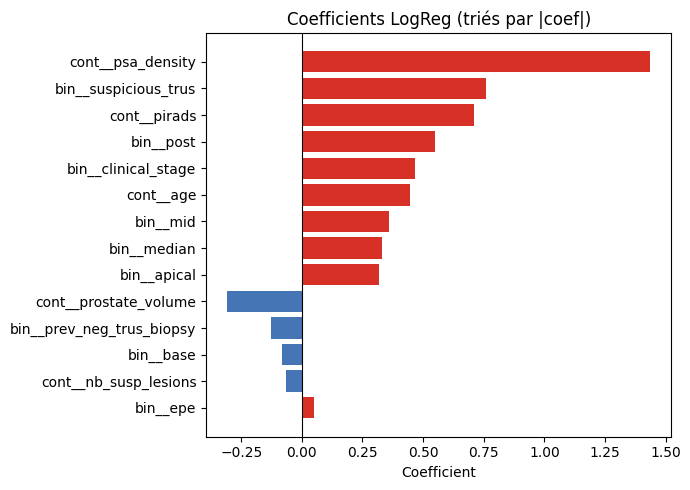

                  feature      coef
        cont__psa_density  1.436968
     bin__suspicious_trus  0.758874
             cont__pirads  0.709631
                bin__post  0.549807
      bin__clinical_stage  0.466884
                cont__age  0.446849
                 bin__mid  0.360189
              bin__median  0.331739
              bin__apical  0.317601
    cont__prostate_volume -0.307686
bin__prev_neg_trus_biopsy -0.125526
                bin__base -0.083433
    cont__nb_susp_lesions -0.065302
                 bin__epe  0.048249


In [30]:
feature_names = pipeline.named_steps["pre"].get_feature_names_out()
coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": pipeline.named_steps["clf"].coef_[0]})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=True)
)

fig, ax = plt.subplots(figsize=(7, max(5, len(coef_df) * 0.35)))
colors = ["#d73027" if v > 0 else "#4575b4" for v in coef_df["coef"]]
ax.barh(coef_df["feature"], coef_df["coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient")
ax.set_title("Coefficients LogReg (triés par |coef|)")
plt.tight_layout()
plt.show()

print(coef_df.drop(columns="abs_coef").sort_values("coef", ascending=False, key=abs).to_string(index=False))

## 6. ROC / PR curve (val)

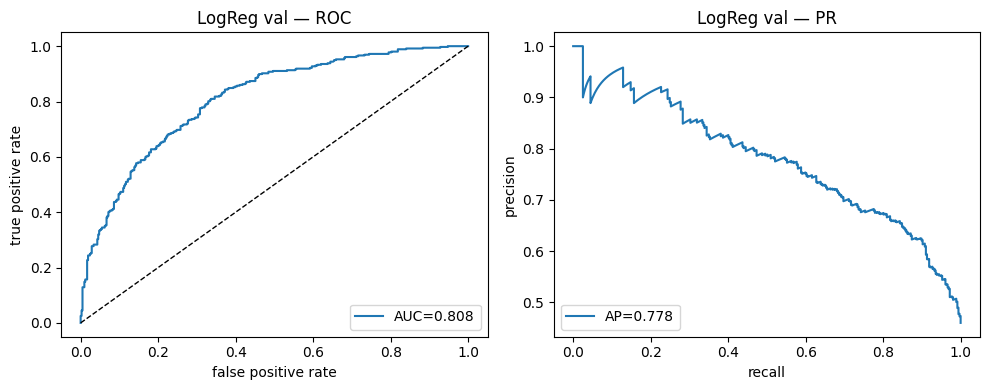

Classification report (threshold=0.5) :
              precision    recall  f1-score   support

           0       0.76      0.71      0.74       419
           1       0.69      0.73      0.71       357

    accuracy                           0.72       776
   macro avg       0.72      0.72      0.72       776
weighted avg       0.73      0.72      0.72       776



In [31]:
y_val_proba = pipeline.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
precision, recall, _ = precision_recall_curve(y_val, y_val_proba)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(fpr, tpr, label=f"AUC={auc_val:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("LogReg val — ROC")
axes[0].legend(loc="lower right")

axes[1].plot(recall, precision, label=f"AP={average_precision_score(y_val, y_val_proba):.3f}")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("LogReg val — PR")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

y_val_pred = (y_val_proba >= common_threshold).astype(int)
print(f"Classification report (threshold={common_threshold}) :")
print(classification_report(y_val, y_val_pred))

## 7. Évaluation sur test set
Contrôlé par `model_logreg.run_test` dans `config.yaml`.

In [32]:
if not RUN_TEST:
    print("RUN_TEST = false — évaluation test skippée.")
else:
    df_test = pd.read_csv(DATA_TEST, sep=";")
    df_test["age"]         = pd.to_numeric(df_test["age"],         errors="coerce")
    df_test["psa_density"] = pd.to_numeric(df_test["psa_density"], errors="coerce")

    to_drop_test = [f for f in existing_to_drop if f in df_test.columns]
    X_test = df_test.drop(columns=to_drop_test + [TARGET_COL])
    y_test = df_test[TARGET_COL]

    if high_nan_critical:
        X_test = X_test.dropna(subset=[c for c in high_nan_critical if c in X_test.columns])
        y_test = y_test.loc[X_test.index]

    auc_test   = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])
    brier_test = brier_score_loss(y_test, pipeline.predict_proba(X_test)[:, 1])
    print(f"auc   - train: {auc_tr:.4f} | val: {auc_val:.4f} | test: {auc_test:.4f}")
    print(f"brier - train: {brier_tr:.4f} | val: {brier_val:.4f} | test: {brier_test:.4f}")

auc   - train: 0.7966 | val: 0.8083 | test: 0.7479
brier - train: 0.1843 | val: 0.1798 | test: 0.2052


## 8. Sauvegarde du run

In [33]:
import json
import pickle
import shutil
from datetime import datetime

RUNS_DIR = ROOT / "runs"
run_id   = "logreg_" + datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir  = RUNS_DIR / run_id
run_dir.mkdir(parents=True, exist_ok=True)

# model
with open(run_dir / "model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

# config
shutil.copy(ROOT / "config.yaml", run_dir / "config.yaml")

# metrics
metrics = {
    "auc":   {"train": round(auc_tr, 4),    "val": round(auc_val, 4),
               "test":  round(auc_test, 4)  if "auc_test"   in dir() else None},
    "brier": {"train": round(brier_tr, 4),  "val": round(brier_val, 4),
               "test":  round(brier_test, 4) if "brier_test" in dir() else None},
}
with open(run_dir / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# metadata
metadata = {
    "model_type": "LogisticRegression",
    "features": list(X_tr.columns),
    "n_features": X_tr.shape[1],
    "target": TARGET_COL,
    "random_state": RANDOM_STATE,
    "hyperparameters": {
        "C": C, "penalty": PENALTY, "max_iter": MAX_ITER,
        "class_weight": "balanced",
        "apply_power_transform": APPLY_POWER_TRANSFORM,
        "tune_C": TUNE_C,
        "imputation_strategy": imputation_strategy,
    },
    "metrics": metrics,
    "features_dropped": existing_to_drop,
}
with open(run_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Run saved: {run_dir}")
print(f"  model.pkl / metrics.json / metadata.json / config.yaml")

Run saved: C:\Users\jonat\Desktop\ECAM\2025_2026\TFE\code\runs\logreg_20260425_181940
  model.pkl / metrics.json / metadata.json / config.yaml
